# Datathon Passos Mágicos - Fase 5
## Parte 3 - Respondendo as perguntas do desafio

Aqui eu respondo, uma por uma, as 11 perguntas propostas no enunciado do datathon.
A exploração inicial dos dados (tipos, valores faltantes, distribuições) está no
notebook `01_eda.ipynb`, e o modelo preditivo está no `02_model_training.ipynb`.

Cada pergunta abaixo tem: o código da análise, o gráfico gerado a partir dele, e a
resposta em texto. Os gráficos são salvos em `presentation/assets_v3/` e são os
mesmos que aparecem na apresentação.

In [1]:
import os
import sys

# sobe a partir da pasta atual ate achar a raiz do projeto, pra funcionar tanto
# abrindo o notebook de dentro de notebooks/ quanto da raiz do repositorio
RAIZ = os.getcwd()
while not os.path.isdir(os.path.join(RAIZ, "src")) and os.path.dirname(RAIZ) != RAIZ:
    RAIZ = os.path.dirname(RAIZ)
sys.path.insert(0, os.path.join(RAIZ, "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_cleaning import load_consolidated

# paleta da Passos Magicos (mesmas cores usadas na apresentacao)
VERMELHO = "#ED3237"
LARANJA  = "#F58334"
AMARELO  = "#FBBA00"
VERDE    = "#37CD8F"
AZUL     = "#5CA7E8"
NAVY     = "#1B2A4A"
CINZA    = "#9AA0A6"

SAIDA = os.path.join(RAIZ, "presentation", "assets_v3")
os.makedirs(SAIDA, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",
})

def salvar(fig, nome):
    """Salva o grafico na pasta usada pela apresentacao."""
    fig.savefig(os.path.join(SAIDA, nome + ".png"), bbox_inches="tight", dpi=150)

df = load_consolidated()
print("Registros aluno-ano:", len(df))
print("Alunos distintos:", df["ra"].nunique())
print("Anos:", sorted(df["ano_pesquisa"].unique()))

Registros aluno-ano: 3030
Alunos distintos: 1661
Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]


---
## Pergunta 1 — Adequação do nível (IAN)

*Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?
Por exemplo: quantos alunos estão moderadamente ou severamente defasados?*

In [2]:
# a coluna "defasagem" diz quantas fases o aluno esta atras (negativo) ou a frente
def faixa_defasagem(d):
    if pd.isna(d):
        return np.nan
    if d <= -2:
        return "Defasagem severa"
    if d == -1:
        return "Defasagem moderada"
    if d == 0:
        return "Adequado"
    return "Adiantado"

df["faixa_defasagem"] = df["defasagem"].apply(faixa_defasagem)

ordem = ["Defasagem severa", "Defasagem moderada", "Adequado", "Adiantado"]
perfil = (df.groupby("ano_pesquisa")["faixa_defasagem"]
            .value_counts(normalize=True).unstack()[ordem] * 100)

print("Distribuicao dos alunos por situacao de defasagem (% por ano)")
print(perfil.round(1))
print()
print("IAN medio por ano:")
print(df.groupby("ano_pesquisa")["ian"].mean().round(2))

Distribuicao dos alunos por situacao de defasagem (% por ano)
faixa_defasagem  Defasagem severa  Defasagem moderada  Adequado  Adiantado
ano_pesquisa                                                              
2022                         22.2                47.7      28.7        1.4
2023                         14.2                40.2      41.4        4.1
2024                          8.0                38.1      42.0       11.9

IAN medio por ano:
ano_pesquisa
2022    6.42
2023    7.24
2024    7.68
Name: ian, dtype: float64


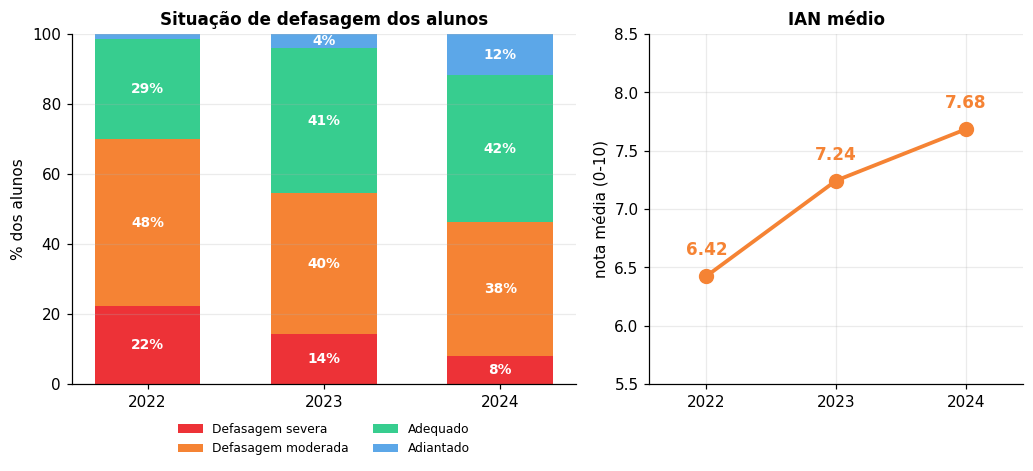

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.4), gridspec_kw={"width_ratios": [1.35, 1]})

cores = [VERMELHO, LARANJA, VERDE, AZUL]
base = np.zeros(len(perfil))
for cor, col in zip(cores, ordem):
    ax1.bar(perfil.index.astype(str), perfil[col], bottom=base, color=cor, label=col, width=0.6)
    for x, (b, v) in enumerate(zip(base, perfil[col])):
        if v >= 4:
            ax1.text(x, b + v / 2, f"{v:.0f}%", ha="center", va="center",
                     color="white", fontsize=9, fontweight="bold")
    base += perfil[col].values

ax1.set_ylabel("% dos alunos")
ax1.set_title("Situação de defasagem dos alunos", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)
ax1.set_ylim(0, 100)
ax1.grid(axis="x")

ian = df.groupby("ano_pesquisa")["ian"].mean()
ax2.plot(ian.index.astype(str), ian.values, marker="o", color=LARANJA, linewidth=2.5, markersize=9)
for x, v in zip(ian.index.astype(str), ian.values):
    ax2.text(x, v + 0.18, f"{v:.2f}", ha="center", color=LARANJA, fontweight="bold", fontsize=11)
ax2.set_ylim(5.5, 8.5)
ax2.margins(x=0.22)
ax2.set_ylabel("nota média (0-10)")
ax2.set_title("IAN médio", fontsize=11, fontweight="bold")

plt.tight_layout()
salvar(fig, "p01_ian")
plt.show()

**Resposta:** a defasagem caiu de forma consistente nos três anos. A fatia de alunos com
defasagem severa (duas fases ou mais atrás) praticamente desapareceu, e o IAN médio subiu de
6,42 para 7,68. É o indicador com a evolução mais clara de todos.

---
## Pergunta 2 — Desempenho acadêmico (IDA)

*O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das
fases e anos?*

In [4]:
ida_ano = df.groupby("ano_pesquisa")["ida"].mean()
ida_fase = df.pivot_table(index="fase_ord", columns="ano_pesquisa", values="ida", aggfunc="mean")

print("IDA medio por ano:")
print(ida_ano.round(2))
print()
print("IDA medio por fase e ano:")
print(ida_fase.round(2))

IDA medio por ano:
ano_pesquisa
2022    6.09
2023    6.66
2024    6.35
Name: ida, dtype: float64

IDA medio por fase e ano:
ano_pesquisa  2022  2023  2024
fase_ord                      
0.0           7.14  7.42  7.32
1.0           6.46  6.81  6.79
2.0           5.41  6.74  6.25
3.0           5.14  5.75  5.35
4.0           6.05  6.00  5.88
5.0           5.87  5.90  6.45
6.0           6.69  6.81  7.23
7.0           5.25  7.81  5.81
8.0            NaN   NaN  8.00


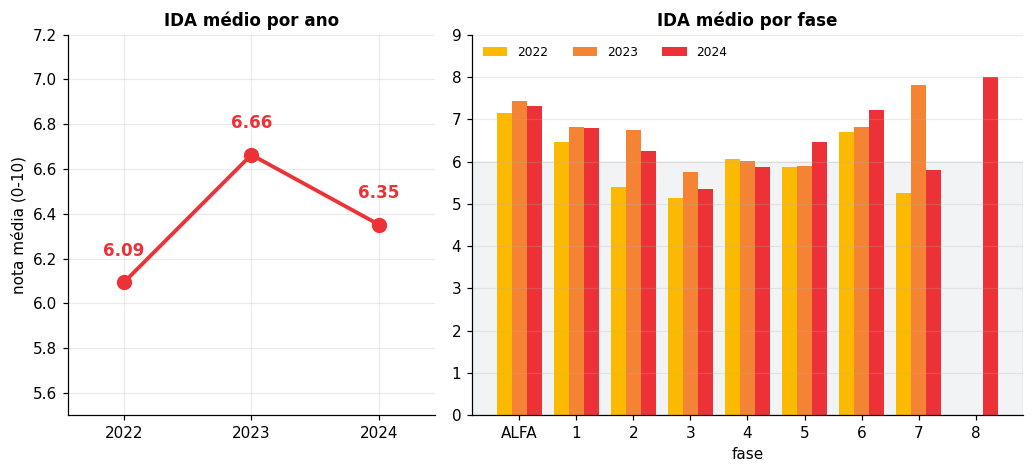

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.4), gridspec_kw={"width_ratios": [1, 1.5]})

ax1.plot(ida_ano.index.astype(str), ida_ano.values, marker="o", color=VERMELHO, linewidth=2.5, markersize=9)
for x, v in zip(ida_ano.index.astype(str), ida_ano.values):
    ax1.text(x, v + 0.12, f"{v:.2f}", ha="center", color=VERMELHO, fontweight="bold", fontsize=11)
ax1.set_ylim(5.5, 7.2)
ax1.margins(x=0.22)
ax1.set_ylabel("nota média (0-10)")
ax1.set_title("IDA médio por ano", fontsize=11, fontweight="bold")

fases = ida_fase.index.astype(int)
larg = 0.26
for i, ano in enumerate(ida_fase.columns):
    ax2.bar(fases + (i - 1) * larg, ida_fase[ano].values, width=larg,
            label=str(ano), color=[AMARELO, LARANJA, VERMELHO][i])
ax2.axhspan(0, 6, color=CINZA, alpha=0.12, zorder=0)
ax2.set_xticks(fases)
ax2.set_xticklabels(["ALFA" if f == 0 else str(f) for f in fases])
ax2.set_xlabel("fase")
ax2.set_ylim(0, 9)
ax2.set_title("IDA médio por fase", fontsize=11, fontweight="bold")
ax2.legend(fontsize=8, frameon=False, ncol=3, loc="upper left")
ax2.grid(axis="x")

plt.tight_layout()
salvar(fig, "p02_ida")
plt.show()

**Resposta:** o IDA não acompanha o IAN. Ele sobe em 2023 e volta a cair em 2024, ficando
praticamente estagnado no período. Olhando por fase, aparece um vale claro nas fases 2 e 3, que
ficam abaixo das demais nos três anos seguidos — é onde o desempenho acadêmico mais sofre.

---
## Pergunta 3 — Engajamento (IEG)

*O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de
desempenho (IDA) e do ponto de virada (IPV)?*

In [6]:
par1 = df[["ieg", "ida"]].dropna()
par2 = df[["ieg", "ipv"]].dropna()
r_ida = par1["ieg"].corr(par1["ida"])
r_ipv = par2["ieg"].corr(par2["ipv"])
print(f"Correlacao IEG x IDA: {r_ida:.2f}  (n={len(par1)})")
print(f"Correlacao IEG x IPV: {r_ipv:.2f}  (n={len(par2)})")

Correlacao IEG x IDA: 0.54  (n=2852)
Correlacao IEG x IPV: 0.56  (n=2852)


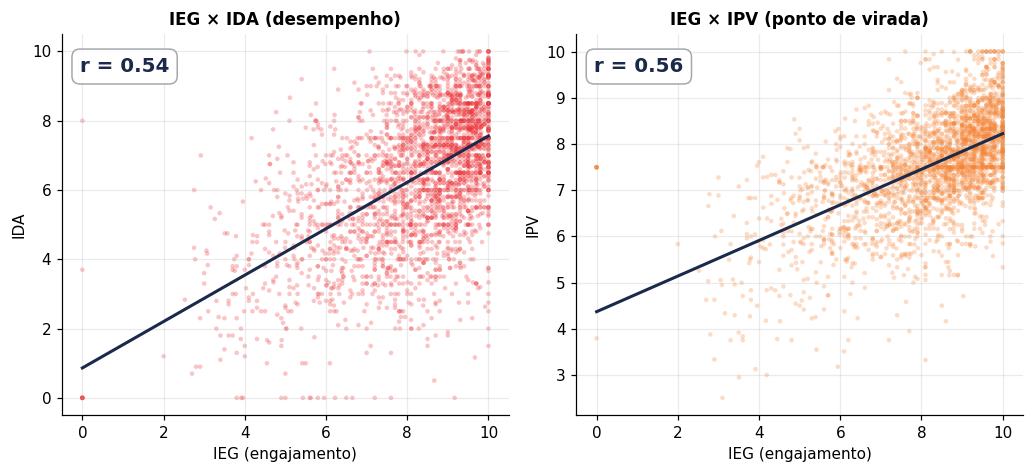

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.4))

for ax, (par, ycol, r, cor, titulo) in zip(axes, [
    (par1, "ida", r_ida, VERMELHO, "IEG × IDA (desempenho)"),
    (par2, "ipv", r_ipv, LARANJA, "IEG × IPV (ponto de virada)"),
]):
    ax.scatter(par["ieg"], par[ycol], s=9, alpha=0.28, color=cor, edgecolors="none")
    z = np.polyfit(par["ieg"], par[ycol], 1)
    xs = np.linspace(par["ieg"].min(), par["ieg"].max(), 50)
    ax.plot(xs, np.polyval(z, xs), color=NAVY, linewidth=2)
    ax.set_xlabel("IEG (engajamento)")
    ax.set_ylabel(ycol.upper())
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.text(0.04, 0.94, f"r = {r:.2f}", transform=ax.transAxes, fontsize=13,
            fontweight="bold", color=NAVY, va="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=CINZA, alpha=0.9))

plt.tight_layout()
salvar(fig, "p03_ieg")
plt.show()

**Resposta:** sim, existe relação nos dois casos, com força moderada (r em torno de 0,5).
Não é uma relação determinística — tem aluno engajado com nota baixa e vice-versa — mas a
tendência é consistente: quanto maior o engajamento, melhores tendem a ser o desempenho e o
ponto de virada.

---
## Pergunta 4 — Autoavaliação (IAA)

*As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA)
e engajamento (IEG)?*

In [8]:
p_ida = df[["iaa", "ida"]].dropna()
p_ieg = df[["iaa", "ieg"]].dropna()
r_aa_ida = p_ida["iaa"].corr(p_ida["ida"])
r_aa_ieg = p_ieg["iaa"].corr(p_ieg["ieg"])

print(f"Correlacao IAA x IDA: {r_aa_ida:.2f}")
print(f"Correlacao IAA x IEG: {r_aa_ieg:.2f}")
print()
medias = df[["iaa", "ieg", "ida"]].mean()
print("Medias gerais:")
print(medias.round(2))
print(f"\nDiferenca IAA - IDA: {medias['iaa'] - medias['ida']:.2f} pontos")

Correlacao IAA x IDA: 0.12
Correlacao IAA x IEG: 0.13

Medias gerais:
iaa    7.92
ieg    7.95
ida    6.38
dtype: float64

Diferenca IAA - IDA: 1.54 pontos


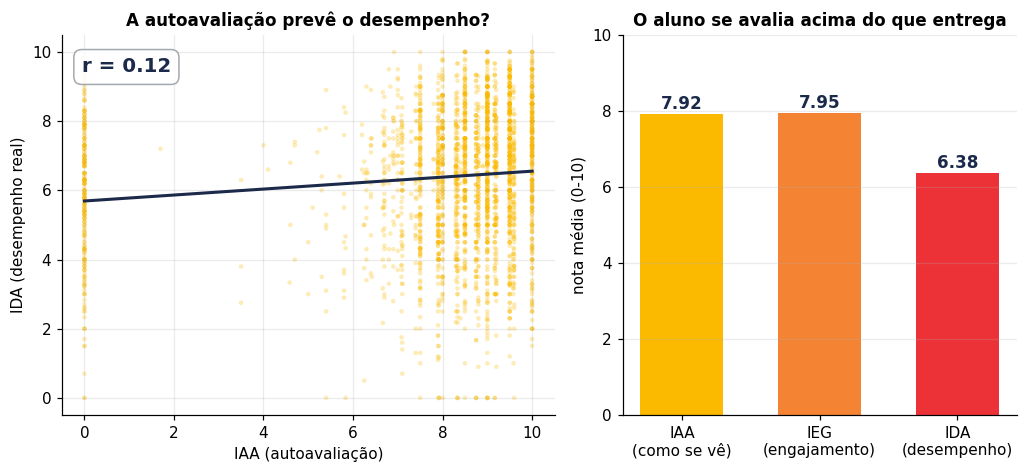

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.4), gridspec_kw={"width_ratios": [1.25, 1]})

ax1.scatter(p_ida["iaa"], p_ida["ida"], s=9, alpha=0.28, color=AMARELO, edgecolors="none")
z = np.polyfit(p_ida["iaa"], p_ida["ida"], 1)
xs = np.linspace(p_ida["iaa"].min(), p_ida["iaa"].max(), 50)
ax1.plot(xs, np.polyval(z, xs), color=NAVY, linewidth=2)
ax1.set_xlabel("IAA (autoavaliação)")
ax1.set_ylabel("IDA (desempenho real)")
ax1.set_title("A autoavaliação prevê o desempenho?", fontsize=11, fontweight="bold")
ax1.text(0.04, 0.94, f"r = {r_aa_ida:.2f}", transform=ax1.transAxes, fontsize=13,
         fontweight="bold", color=NAVY, va="top",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=CINZA, alpha=0.9))

nomes = ["IAA\n(como se vê)", "IEG\n(engajamento)", "IDA\n(desempenho)"]
vals = [medias["iaa"], medias["ieg"], medias["ida"]]
barras = ax2.bar(nomes, vals, color=[AMARELO, LARANJA, VERMELHO], width=0.6)
for b, v in zip(barras, vals):
    ax2.text(b.get_x() + b.get_width() / 2, v + 0.12, f"{v:.2f}", ha="center",
             fontweight="bold", fontsize=11, color=NAVY)
ax2.set_ylim(0, 10)
ax2.set_ylabel("nota média (0-10)")
ax2.set_title("O aluno se avalia acima do que entrega", fontsize=11, fontweight="bold")
ax2.grid(axis="x")

plt.tight_layout()
salvar(fig, "p04_iaa")
plt.show()

**Resposta:** não são muito coerentes. A correlação entre autoavaliação e desempenho real é
baixa, e na média os alunos se avaliam bem acima da nota que efetivamente tiram. Ou seja, a
autoavaliação sozinha não serve como sinal de alerta — ela é mais otimista do que a realidade.

---
## Pergunta 5 — Aspectos psicossociais (IPS)

*Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de
engajamento?*

In [10]:
# junta cada aluno com o registro dele do ano seguinte pra ver quem caiu
prox = df[["ra", "ano_pesquisa", "ida", "ieg"]].copy()
prox["ano_pesquisa"] -= 1
prox = prox.rename(columns={"ida": "ida_prox", "ieg": "ieg_prox"})

pares = df.merge(prox, on=["ra", "ano_pesquisa"], how="inner")
pares["caiu_ida"] = pares["ida_prox"] < pares["ida"]
pares["caiu_ieg"] = pares["ieg_prox"] < pares["ieg"]

comp = pd.DataFrame({
    "Caiu no ano seguinte": [pares.loc[pares.caiu_ida, "ips"].mean(),
                             pares.loc[pares.caiu_ieg, "ips"].mean()],
    "Não caiu":             [pares.loc[~pares.caiu_ida, "ips"].mean(),
                             pares.loc[~pares.caiu_ieg, "ips"].mean()],
}, index=["Queda de desempenho (IDA)", "Queda de engajamento (IEG)"])

print("IPS medio no ano ANTERIOR ao evento:")
print(comp.round(2))
print()
print("n de pares aluno-ano:", len(pares))
print("cairam em IDA:", int(pares.caiu_ida.sum()), "| cairam em IEG:", int(pares.caiu_ieg.sum()))

IPS medio no ano ANTERIOR ao evento:
                            Caiu no ano seguinte  Não caiu
Queda de desempenho (IDA)                   5.87      6.06
Queda de engajamento (IEG)                  5.70      6.24

n de pares aluno-ano: 1365
cairam em IDA: 674 | cairam em IEG: 675


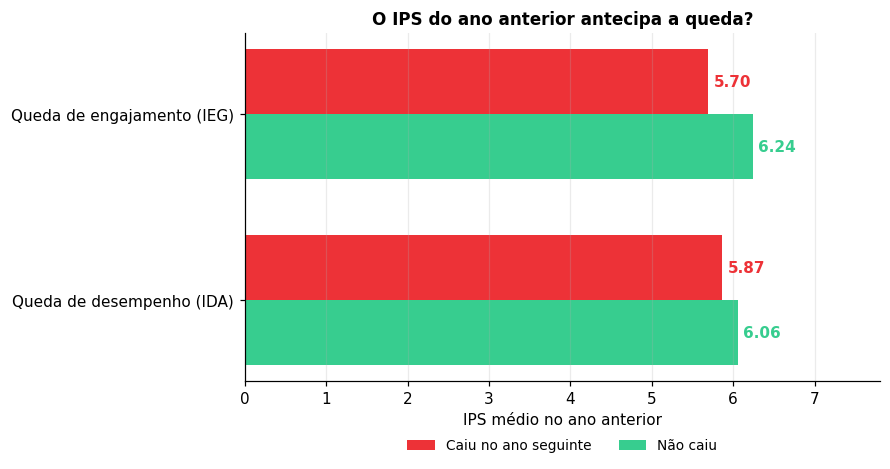

In [11]:
fig, ax = plt.subplots(figsize=(8.2, 4.4))

y = np.arange(len(comp))
alt = 0.35
ax.barh(y + alt/2, comp["Caiu no ano seguinte"], height=alt, color=VERMELHO, label="Caiu no ano seguinte")
ax.barh(y - alt/2, comp["Não caiu"], height=alt, color=VERDE, label="Não caiu")

for i in range(len(comp)):
    ax.text(comp["Caiu no ano seguinte"].iloc[i] + 0.06, y[i] + alt/2,
            f'{comp["Caiu no ano seguinte"].iloc[i]:.2f}', va="center", fontweight="bold", fontsize=10, color=VERMELHO)
    ax.text(comp["Não caiu"].iloc[i] + 0.06, y[i] - alt/2,
            f'{comp["Não caiu"].iloc[i]:.2f}', va="center", fontweight="bold", fontsize=10, color=VERDE)

ax.set_yticks(y)
ax.set_yticklabels(comp.index)
ax.set_xlabel("IPS médio no ano anterior")
ax.set_xlim(0, max(comp.max()) * 1.25)
ax.set_title("O IPS do ano anterior antecipa a queda?", fontsize=11, fontweight="bold")
ax.legend(fontsize=9, frameon=False, loc="upper center",
          bbox_to_anchor=(0.5, -0.13), ncol=2)
ax.grid(axis="y")

plt.tight_layout()
salvar(fig, "p05_ips")
plt.show()

**Resposta:** existe um sinal, mas ele é fraco. Quem cai de desempenho no ano seguinte já
vinha com IPS um pouco mais baixo, porém a diferença é pequena demais para servir como alerta
isolado. O IPS ajuda como peça de um conjunto de indicadores, não sozinho.

---
## Pergunta 6 — Aspectos psicopedagógicos (IPP)

*As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada
pelo IAN?*

In [12]:
sub = df[["ipp", "ian", "faixa_defasagem"]].dropna(subset=["ipp", "ian"])
r_ipp_ian = sub["ipp"].corr(sub["ian"])
print(f"Correlacao IPP x IAN: {r_ipp_ian:.2f}  (n={len(sub)})")
print()
por_faixa = sub.groupby("faixa_defasagem")["ipp"].agg(["mean", "count"]).round(2)
print("IPP medio por situacao de defasagem:")
print(por_faixa)

Correlacao IPP x IAN: 0.12  (n=1992)

IPP medio por situacao de defasagem:
                    mean  count
faixa_defasagem                
Adequado            7.64    778
Adiantado           7.93    130
Defasagem moderada  7.55    847
Defasagem severa    7.11    237


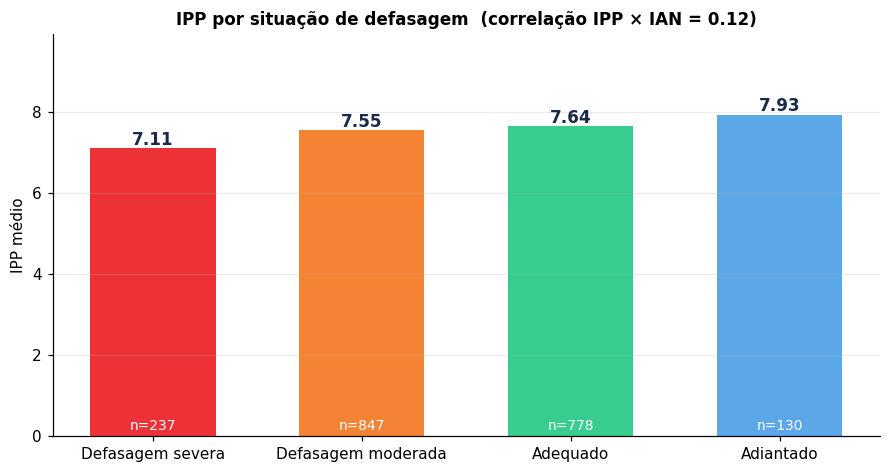

In [13]:
fig, ax = plt.subplots(figsize=(8.2, 4.4))

presentes = [f for f in ordem if f in por_faixa.index]
vals = [por_faixa.loc[f, "mean"] for f in presentes]
ns = [int(por_faixa.loc[f, "count"]) for f in presentes]
cores_f = {"Defasagem severa": VERMELHO, "Defasagem moderada": LARANJA,
           "Adequado": VERDE, "Adiantado": AZUL}

barras = ax.bar(presentes, vals, color=[cores_f[f] for f in presentes], width=0.6)
for b, v, n in zip(barras, vals, ns):
    ax.text(b.get_x() + b.get_width()/2, v + 0.08, f"{v:.2f}", ha="center",
            fontweight="bold", fontsize=11, color=NAVY)
    ax.text(b.get_x() + b.get_width()/2, 0.15, f"n={n}", ha="center", fontsize=9, color="white")

ax.set_ylabel("IPP médio")
ax.set_ylim(0, max(vals) * 1.25)
ax.set_title(f"IPP por situação de defasagem  (correlação IPP × IAN = {r_ipp_ian:.2f})",
             fontsize=11, fontweight="bold")
ax.grid(axis="x")

plt.tight_layout()
salvar(fig, "p06_ipp")
plt.show()

**Resposta:** o IPP confirma a direção apontada pelo IAN — alunos mais defasados têm IPP
médio mais baixo — mas a relação é fraca. São indicadores complementares: medem coisas
diferentes e não devem ser lidos como substitutos um do outro.

---
## Pergunta 7 — Ponto de virada (IPV)

*Quais comportamentos — acadêmicos, emocionais ou de engajamento — mais influenciam o IPV
ao longo do tempo?*

In [14]:
candidatos = ["ipp", "ieg", "ida", "ips", "iaa", "ian"]
corr_ipv = df[candidatos + ["ipv"]].corr()["ipv"].drop("ipv").sort_values(ascending=False)
print("Correlacao de cada indicador com o IPV:")
print(corr_ipv.round(2))

Correlacao de cada indicador com o IPV:
ipp    0.61
ieg    0.56
ida    0.56
ian    0.15
iaa    0.06
ips   -0.05
Name: ipv, dtype: float64


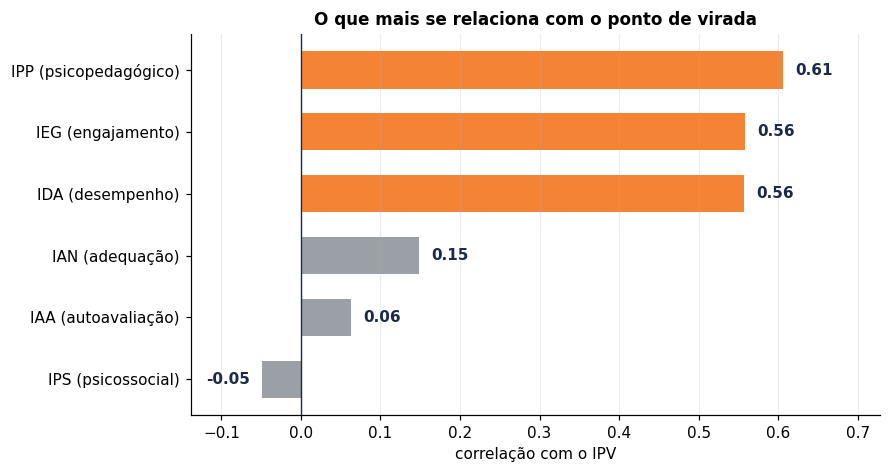

In [15]:
fig, ax = plt.subplots(figsize=(8.2, 4.4))

rot = {"ipp": "IPP (psicopedagógico)", "ieg": "IEG (engajamento)", "ida": "IDA (desempenho)",
       "ips": "IPS (psicossocial)", "iaa": "IAA (autoavaliação)", "ian": "IAN (adequação)"}
vals = corr_ipv.values[::-1]
nomes = [rot[i] for i in corr_ipv.index][::-1]
cores_b = [LARANJA if v >= 0.5 else (AMARELO if v >= 0.3 else CINZA) for v in vals]

barras = ax.barh(nomes, vals, color=cores_b, height=0.6)
for b, v in zip(barras, vals):
    desloc = 0.015 if v >= 0 else -0.015
    ax.text(v + desloc, b.get_y() + b.get_height()/2, f"{v:.2f}", va="center",
            ha="left" if v >= 0 else "right",
            fontweight="bold", fontsize=10, color=NAVY)

ax.axvline(0, color=NAVY, linewidth=0.9)
ax.set_xlabel("correlação com o IPV")
ax.set_xlim(min(0, min(vals)) - 0.09, max(vals) * 1.2)
ax.set_title("O que mais se relaciona com o ponto de virada", fontsize=11, fontweight="bold")
ax.grid(axis="y")

plt.tight_layout()
salvar(fig, "p07_ipv")
plt.show()

**Resposta:** o IPV está mais ligado ao acompanhamento psicopedagógico (IPP) e ao
engajamento (IEG), com o desempenho acadêmico (IDA) logo atrás. Ou seja: a virada na trajetória
do aluno tem mais a ver com acompanhamento e envolvimento do que com nota isolada.

---
## Pergunta 8 — Multidimensionalidade dos indicadores

*Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do
aluno (INDE)?*

In [16]:
comps = ["ida", "ieg", "ips", "ipp", "ipv", "iaa", "ian"]
corr_inde = df[comps + ["inde"]].corr()["inde"].drop("inde").sort_values(ascending=False)
print("Correlacao de cada indicador com o INDE:")
print(corr_inde.round(2))
print()

# quanto o INDE muda quando o aluno esta acima da mediana em 1, 2, 3 ou 4 dos indicadores-chave
chave = ["ida", "ieg", "ips", "ipp"]
d = df.dropna(subset=chave + ["inde"]).copy()
for c in chave:
    d[f"alto_{c}"] = d[c] > d[c].median()
d["n_altos"] = d[[f"alto_{c}" for c in chave]].sum(axis=1)
por_n = d.groupby("n_altos")["inde"].agg(["mean", "count"]).round(2)
print("INDE medio por quantidade de indicadores acima da mediana (IDA, IEG, IPS, IPP):")
print(por_n)

Correlacao de cada indicador com o INDE:
ida    0.79
ieg    0.75
ipv    0.72
ipp    0.54
ian    0.41
iaa    0.40
ips    0.20
Name: inde, dtype: float64

INDE medio por quantidade de indicadores acima da mediana (IDA, IEG, IPS, IPP):
         mean  count
n_altos             
0        6.11    249
1        6.74    495
2        7.47    526
3        8.05    490
4        8.44    225


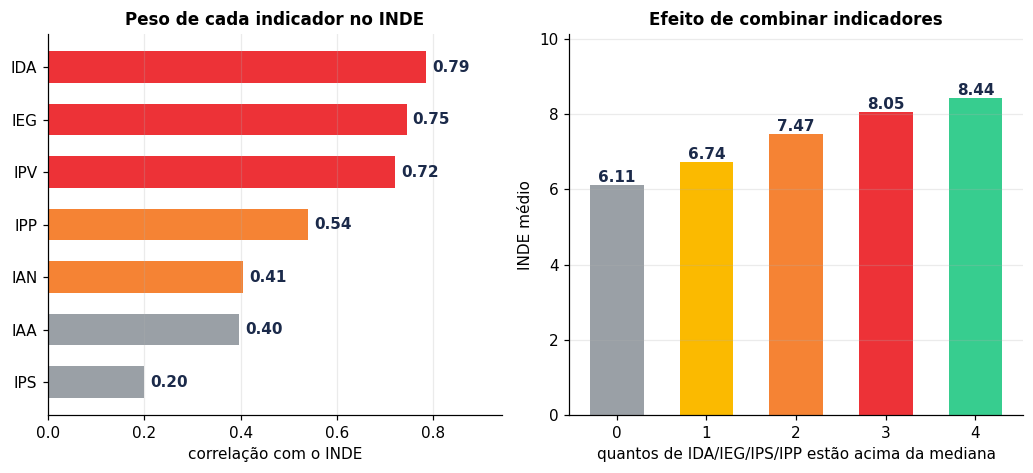

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.4))

rot2 = {"ida": "IDA", "ieg": "IEG", "ipv": "IPV", "ipp": "IPP",
        "ips": "IPS", "iaa": "IAA", "ian": "IAN"}
vals = corr_inde.values[::-1]
nomes = [rot2[i] for i in corr_inde.index][::-1]
barras = ax1.barh(nomes, vals, color=[VERMELHO if v >= 0.6 else (LARANJA if v >= 0.4 else CINZA) for v in vals], height=0.6)
for b, v in zip(barras, vals):
    ax1.text(v + 0.012, b.get_y() + b.get_height()/2, f"{v:.2f}", va="center",
             fontweight="bold", fontsize=10, color=NAVY)
ax1.set_xlabel("correlação com o INDE")
ax1.set_xlim(0, max(vals) * 1.2)
ax1.set_title("Peso de cada indicador no INDE", fontsize=11, fontweight="bold")
ax1.grid(axis="y")

xs = por_n.index.astype(int)
ys = por_n["mean"].values
barras2 = ax2.bar(xs, ys, color=[CINZA, AMARELO, LARANJA, VERMELHO, VERDE][:len(xs)], width=0.6)
for b, v in zip(barras2, ys):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.08, f"{v:.2f}", ha="center",
             fontweight="bold", fontsize=10, color=NAVY)
ax2.set_xlabel("quantos de IDA/IEG/IPS/IPP estão acima da mediana")
ax2.set_ylabel("INDE médio")
ax2.set_ylim(0, max(ys) * 1.2)
ax2.set_title("Efeito de combinar indicadores", fontsize=11, fontweight="bold")
ax2.grid(axis="x")

plt.tight_layout()
salvar(fig, "p08_inde")
plt.show()

**Resposta:** o INDE é puxado principalmente por IDA, IEG e IPV. E o efeito é cumulativo:
o aluno que está acima da mediana nos quatro indicadores-chave ao mesmo tempo tem INDE bem
maior do que quem está bem em apenas um. Não existe um indicador que sozinho resolva — é a
combinação que eleva a nota global.

---
## Pergunta 9 — Previsão de risco com Machine Learning

*Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no
desempenho ou aumento da defasagem?*

O modelo em si (feature engineering, treino/teste, avaliação) está no notebook
`02_model_training.ipynb`. Aqui eu mostro **quais indicadores separam** os alunos que entram em
risco dos que não entram — que é o padrão que o modelo aprende.

In [18]:
# mesmo alvo usado no notebook 02: risco de defasagem no ano SEGUINTE
prox_r = df[["ra", "ano_pesquisa", "defasagem", "ian"]].copy()
prox_r["ano_pesquisa"] -= 1
prox_r["risco_next"] = ((prox_r["defasagem"] < 0) | (prox_r["ian"] < 5)).astype(int)
prox_r = prox_r[["ra", "ano_pesquisa", "risco_next"]]

base = df.merge(prox_r, on=["ra", "ano_pesquisa"], how="inner")
print("Pares aluno-ano disponiveis para o modelo:", len(base))
print(base["risco_next"].value_counts(normalize=True).round(3).to_string())
print()

inds = ["ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv", "inde"]
perfil_risco = base.groupby("risco_next")[inds].mean().T
perfil_risco.columns = ["Sem risco", "Em risco"]
perfil_risco["diferença"] = perfil_risco["Sem risco"] - perfil_risco["Em risco"]
print("Media de cada indicador no ano anterior, por grupo:")
print(perfil_risco.round(2).sort_values("diferença", ascending=False))

Pares aluno-ano disponiveis para o modelo: 1365
risco_next
0    0.506
1    0.494

Media de cada indicador no ano anterior, por grupo:
      Sem risco  Em risco  diferença
ian        8.00      6.02       1.98
ipp        8.01      7.12       0.89
ida        7.04      6.31       0.72
ipv        8.16      7.48       0.68
inde       7.68      7.08       0.60
ieg        8.88      8.35       0.53
iaa        7.62      7.70      -0.09
ips        5.65      6.25      -0.60


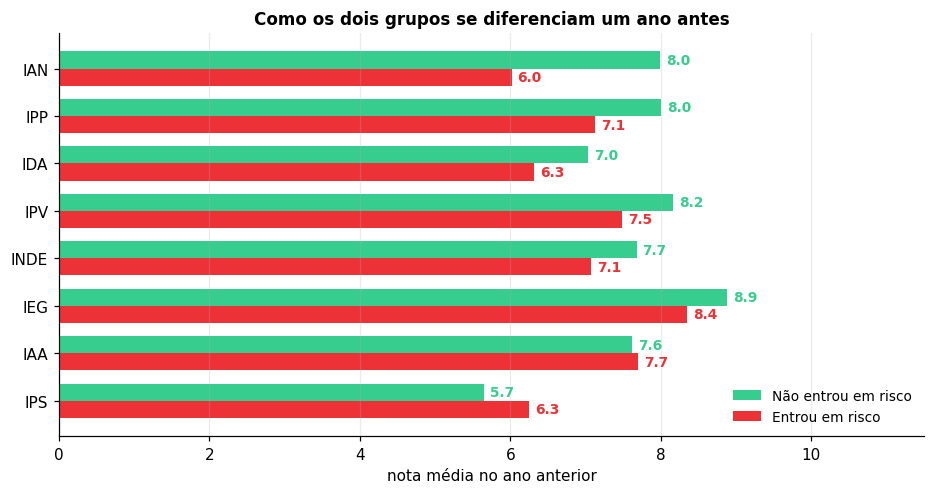

In [19]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))

pr = perfil_risco.sort_values("diferença")
y = np.arange(len(pr))
alt = 0.36
ax.barh(y + alt/2, pr["Sem risco"], height=alt, color=VERDE, label="Não entrou em risco")
ax.barh(y - alt/2, pr["Em risco"], height=alt, color=VERMELHO, label="Entrou em risco")

for i in range(len(pr)):
    ax.text(pr["Sem risco"].iloc[i] + 0.08, y[i] + alt/2, f'{pr["Sem risco"].iloc[i]:.1f}',
            va="center", fontsize=9, color=VERDE, fontweight="bold")
    ax.text(pr["Em risco"].iloc[i] + 0.08, y[i] - alt/2, f'{pr["Em risco"].iloc[i]:.1f}',
            va="center", fontsize=9, color=VERMELHO, fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels([i.upper() for i in pr.index])
ax.set_xlabel("nota média no ano anterior")
ax.set_xlim(0, 11.5)
ax.set_title("Como os dois grupos se diferenciam um ano antes", fontsize=11, fontweight="bold")
ax.legend(fontsize=9, frameon=False, loc="lower right")
ax.grid(axis="y")

plt.tight_layout()
salvar(fig, "p09_risco")
plt.show()

**Resposta:** os alunos que entram em risco já se diferenciam um ano antes, principalmente
em IAN e INDE. Isso é justamente o que torna a previsão possível: o sinal existe antes do
problema aparecer. O modelo treinado no notebook `02_model_training.ipynb` aproveita esses
padrões para estimar a probabilidade de risco de cada aluno.

---
## Pergunta 10 — Efetividade do programa

*Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo,
Ágata, Ametista e Topázio), confirmando o impacto real do programa?*

In [20]:
ordem_pedra = ["Quartzo", "Ágata", "Ametista", "Topázio"]
pedra = (df.groupby("ano_pesquisa")["pedra"].value_counts(normalize=True)
           .unstack()[ordem_pedra] * 100)
print("Distribuicao dos alunos por pedra (% por ano):")
print(pedra.round(1))
print()
print("INDE medio por ano:")
print(df.groupby("ano_pesquisa")["inde"].mean().round(2))

Distribuicao dos alunos por pedra (% por ano):
pedra         Quartzo  Ágata  Ametista  Topázio
ano_pesquisa                                   
2022             15.3   29.1      40.5     15.1
2023              7.7   26.4      40.9     24.9
2024             10.6   21.3      37.1     30.9

INDE medio por ano:
ano_pesquisa
2022    7.04
2023    7.34
2024    7.40
Name: inde, dtype: float64


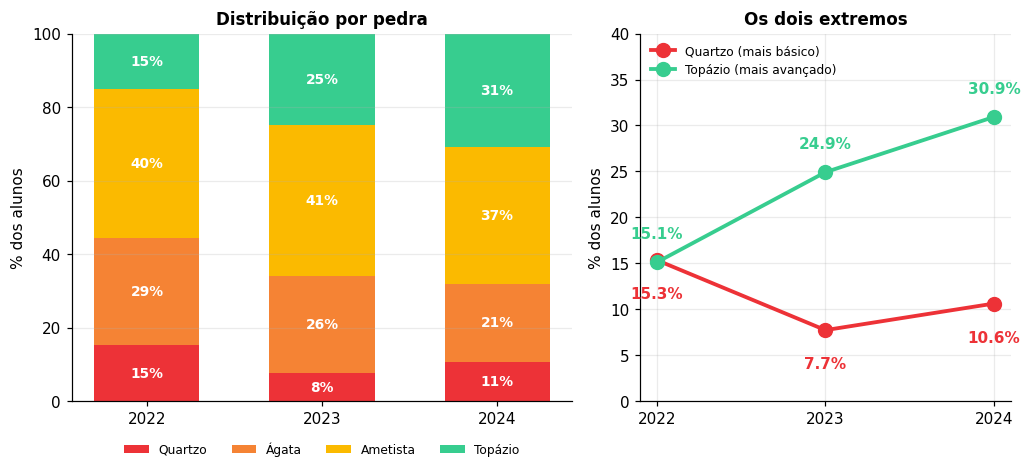

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.4), gridspec_kw={"width_ratios": [1.35, 1]})

cores_p = [VERMELHO, LARANJA, AMARELO, VERDE]
base_p = np.zeros(len(pedra))
for cor, col in zip(cores_p, ordem_pedra):
    ax1.bar(pedra.index.astype(str), pedra[col], bottom=base_p, color=cor, label=col, width=0.6)
    for x, (b, v) in enumerate(zip(base_p, pedra[col])):
        if v >= 5:
            ax1.text(x, b + v/2, f"{v:.0f}%", ha="center", va="center",
                     color="white", fontsize=9, fontweight="bold")
    base_p += pedra[col].values

ax1.set_ylabel("% dos alunos")
ax1.set_ylim(0, 100)
ax1.set_title("Distribuição por pedra", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)
ax1.grid(axis="x")

extremos = pd.DataFrame({"Quartzo": pedra["Quartzo"], "Topázio": pedra["Topázio"]})
ax2.plot(extremos.index.astype(str), extremos["Quartzo"], marker="o", color=VERMELHO,
         linewidth=2.5, markersize=9, label="Quartzo (mais básico)")
ax2.plot(extremos.index.astype(str), extremos["Topázio"], marker="o", color=VERDE,
         linewidth=2.5, markersize=9, label="Topázio (mais avançado)")
for x, v in zip(extremos.index.astype(str), extremos["Quartzo"]):
    ax2.text(x, v - 4.2, f"{v:.1f}%", ha="center", color=VERMELHO, fontweight="bold", fontsize=10)
for x, v in zip(extremos.index.astype(str), extremos["Topázio"]):
    ax2.text(x, v + 2.6, f"{v:.1f}%", ha="center", color=VERDE, fontweight="bold", fontsize=10)
ax2.set_ylabel("% dos alunos")
ax2.set_ylim(0, 40)
ax2.set_title("Os dois extremos", fontsize=11, fontweight="bold")
ax2.legend(fontsize=8, frameon=False, loc="upper left")

plt.tight_layout()
salvar(fig, "p10_efetividade")
plt.show()

**Resposta:** sim. A fatia de alunos na pedra mais básica (Quartzo) diminui e a fatia na
pedra mais avançada (Topázio) mais que dobra ao longo dos três anos. Esse deslocamento para
cima é um indício consistente de que o programa está elevando o nível educacional dos alunos
atendidos.

---
## Pergunta 11 — Insights e criatividade

*Você pode adicionar mais insights e pontos de vista não abordados nas perguntas, utilize a
criatividade e a análise dos dados para trazer sugestões para a Passos Mágicos.*

Duas coisas me chamaram atenção enquanto eu explorava os dados e que nenhuma das perguntas
anteriores cobre.

In [22]:
# quem sai do programa de um ano pro outro?
linhas = []
for ini, fim in [(2022, 2023), (2023, 2024)]:
    a = df[df.ano_pesquisa == ini].copy()
    presentes = set(df[df.ano_pesquisa == fim]["ra"])
    a["saiu"] = ~a["ra"].isin(presentes)
    g = a.groupby("saiu")[["ida", "ieg", "inde"]].mean()
    linhas.append({
        "periodo": f"{ini} → {fim}",
        "saíram": int(a["saiu"].sum()),
        "ficaram": int((~a["saiu"]).sum()),
        "IDA saíram": g.loc[True, "ida"], "IDA ficaram": g.loc[False, "ida"],
        "IEG saíram": g.loc[True, "ieg"], "IEG ficaram": g.loc[False, "ieg"],
    })
evasao = pd.DataFrame(linhas).set_index("periodo")
print("Perfil de quem sai do programa (medias no ano anterior a saida):")
print(evasao.round(2).to_string())
print()
for a in [2022, 2023, 2024]:
    print(f"{a}: {df[df.ano_pesquisa == a]['ra'].nunique()} alunos")

Perfil de quem sai do programa (medias no ano anterior a saida):
             saíram  ficaram  IDA saíram  IDA ficaram  IEG saíram  IEG ficaram
periodo                                                                       
2022 → 2023     260      600        5.23         6.47        6.95         8.30
2023 → 2024     249      765        6.20         6.83        8.23         8.86

2022: 860 alunos
2023: 1014 alunos
2024: 1156 alunos


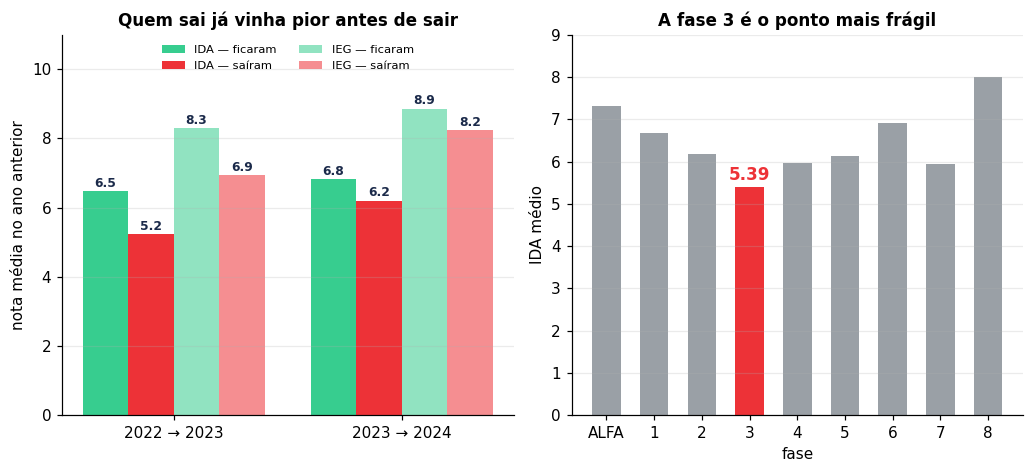

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.4))

x = np.arange(len(evasao))
larg = 0.2
grupos = [
    (x - 1.5*larg, evasao["IDA ficaram"], VERDE, 1.0, "IDA — ficaram"),
    (x - 0.5*larg, evasao["IDA saíram"],  VERMELHO, 1.0, "IDA — saíram"),
    (x + 0.5*larg, evasao["IEG ficaram"], VERDE, 0.55, "IEG — ficaram"),
    (x + 1.5*larg, evasao["IEG saíram"],  VERMELHO, 0.55, "IEG — saíram"),
]
for px, vals_g, cor, alfa, rot_g in grupos:
    ax1.bar(px, vals_g, larg, color=cor, alpha=alfa, label=rot_g)
    for xi, vi in zip(px, vals_g):
        ax1.text(xi, vi + 0.12, f"{vi:.1f}", ha="center", fontsize=8,
                 fontweight="bold", color=NAVY)
ax1.set_xticks(x)
ax1.set_xticklabels(evasao.index)
ax1.set_ylabel("nota média no ano anterior")
ax1.set_ylim(0, 11)
ax1.set_title("Quem sai já vinha pior antes de sair", fontsize=11, fontweight="bold")
ax1.legend(fontsize=7.5, frameon=False, ncol=2, loc="upper center")
ax1.grid(axis="x")

fases_ida = df.groupby("fase_ord")["ida"].mean().dropna()
cores_v = [VERMELHO if v == fases_ida.min() else CINZA for v in fases_ida.values]
barras = ax2.bar(fases_ida.index.astype(int), fases_ida.values, color=cores_v, width=0.6)
pior = fases_ida.idxmin()
ax2.text(pior, fases_ida.min() + 0.18, f"{fases_ida.min():.2f}", ha="center",
         fontweight="bold", color=VERMELHO, fontsize=11)
ax2.set_xticks(fases_ida.index.astype(int))
ax2.set_xticklabels(["ALFA" if f == 0 else str(int(f)) for f in fases_ida.index])
ax2.set_xlabel("fase")
ax2.set_ylabel("IDA médio")
ax2.set_ylim(0, 9)
ax2.set_title("A fase 3 é o ponto mais frágil", fontsize=11, fontweight="bold")
ax2.grid(axis="x")

plt.tight_layout()
salvar(fig, "p11_insights")
plt.show()

**Insight 1 — a evasão é seletiva.** Quem deixa o programa já vinha, no ano anterior, com
desempenho e engajamento bem abaixo de quem ficou. Isso tem duas consequências: primeiro, a
queda de engajamento serve como aviso antecipado de evasão, não só de nota; segundo, parte da
melhora observada nas médias dos indicadores vem da mudança de composição da turma (os alunos
mais frágeis saem), e não apenas de progresso individual — vale ler os resultados da pergunta 10
com essa ressalva.

**Insight 2 — a fase 3 é o gargalo.** É a fase com o pior desempenho acadêmico médio, de forma
consistente nos três anos. É onde um reforço direcionado tende a render mais por aluno atendido.

**Sugestões para a Passos Mágicos:** criar um alerta automático de queda de engajamento (o IEG
cai antes da saída), concentrar reforço acadêmico nas fases 2 e 3, e usar o modelo do notebook
02 como apoio à priorização — nunca como decisão isolada sobre o aluno.

---
## Resumo

| # | Pergunta | Resposta curta |
|---|---|---|
| 1 | Perfil de defasagem (IAN) | Melhora clara: defasagem severa quase zerada, IAN 6,42 → 7,68 |
| 2 | Desempenho (IDA) | Estagnado; vale nas fases 2 e 3 |
| 3 | Engajamento (IEG) | Relação moderada com IDA e IPV |
| 4 | Autoavaliação (IAA) | Pouco coerente com o desempenho real; otimista demais |
| 5 | Psicossocial (IPS) | Sinal fraco, serve só em conjunto |
| 6 | Psicopedagógico (IPP) | Confirma o IAN na direção, mas com relação fraca |
| 7 | Ponto de virada (IPV) | Puxado por IPP e IEG |
| 8 | Multidimensionalidade | INDE puxado por IDA/IEG/IPV; efeito cumulativo |
| 9 | Previsão de risco | Grupos já se separam um ano antes (ver notebook 02) |
| 10 | Efetividade | Sim: Quartzo cai, Topázio mais que dobra |
| 11 | Insights | Evasão seletiva e gargalo na fase 3 |